# Experiment: APS Failure Classification (Revised)

## Dataset Choice (Original size in 50k-100k range)
- **Dataset:** APS Failure at Scania Trucks (OpenML: `APSFailure`)
- **Original size:** **76,000 rows**, 170 features
- **Task:** Binary classification (`pos` = component failure, `neg` = non-failure)



In [2]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42
CACHE_DIR = 'output-revised/data-cache-openml'
SEED


42

## 1. Obtain a dataset and frame the predictive problem

Dataset chosen: **APSFailure** (OpenML), original size **76,000 rows** and 170 features.

Target and prediction type:
- Target variable: APS failure label (`pos` / `neg`)
- Prediction type: **binary classification**

Success metrics and constraints:
- Primary metric: `recall` for `pos` class (failure detection sensitivity)
- Secondary metrics: precision (`pos`), macro F1, and accuracy
- Constraints: class imbalance, runtime practicality, leakage-safe preprocessing, and interpretability

Assumptions and limitations:
- Labels are reliable enough for supervised learning
- Train/test are distributionally similar
- High imbalance can inflate accuracy and hide failure-mode errors

Agent tooling plan:
- Ask agent to scaffold notebook sections and model comparison code
- Ask agent to propose EDA and preprocessing options
- Manually verify dataset size, metric alignment, leakage risks, and interpretation correctness


In [3]:
X_raw, y_raw = fetch_openml(
    name='APSFailure',
    version=1,
    return_X_y=True,
    as_frame=True,
    data_home=CACHE_DIR,
)

print('Original dataset shape:', X_raw.shape)
print('Target distribution:')
print(y_raw.value_counts())


Original dataset shape: (76000, 170)
Target distribution:
class
neg    74625
pos     1375
Name: count, dtype: int64


## 2. Explore the data to gain insights

Concise visual EDA focus:
- Class distribution
- Missingness profile
- Leakage risk checks
- Modelling pitfalls under heavy imbalance

Data quality issues to identify:
- Non-numeric values requiring coercion
- Missing values requiring imputation
- Rare positive class (`pos`) requiring imbalance-aware evaluation

Agent tooling expectation:
- Agent may propose EDA/plots, but all plot interpretations are validated against computed statistics


In [4]:
X = X_raw.apply(pd.to_numeric, errors='coerce')
y = (y_raw == 'pos').astype(int)

# Use all rows (76,000 observations)
X_s = X.copy()
y_s = y.copy()

print('Working dataset shape:', X_s.shape)
print('Working target distribution:')
print(y_s.value_counts())


Working dataset shape: (76000, 170)
Working target distribution:
class
0    74625
1     1375
Name: count, dtype: int64


### Missingness Plot (Top 20 Features)

This plot shows which features have the highest missing-value percentage, supporting the median-imputation choice.


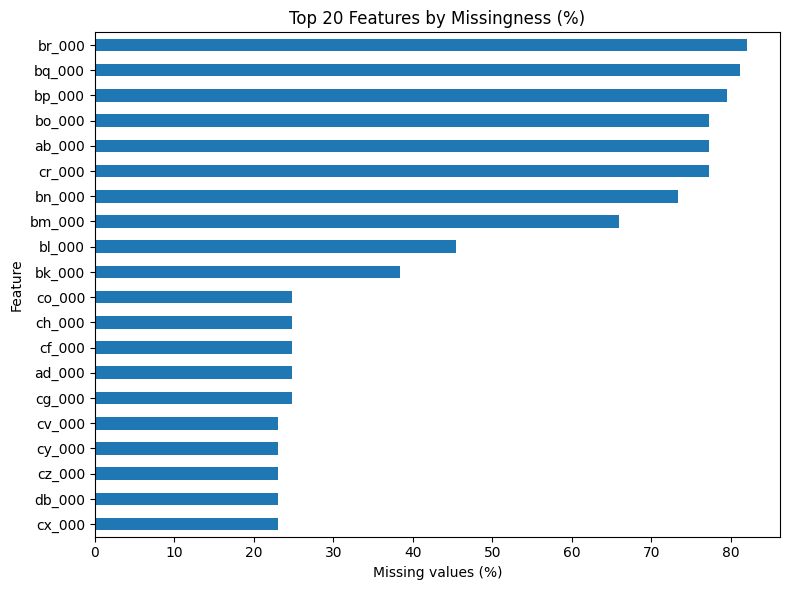

In [5]:
missing_pct = X_s.isna().mean().sort_values(ascending=False) * 100
top_missing = missing_pct.head(20).sort_values()

ax = top_missing.plot(kind='barh', figsize=(8, 6), title='Top 20 Features by Missingness (%)')
ax.set_xlabel('Missing values (%)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


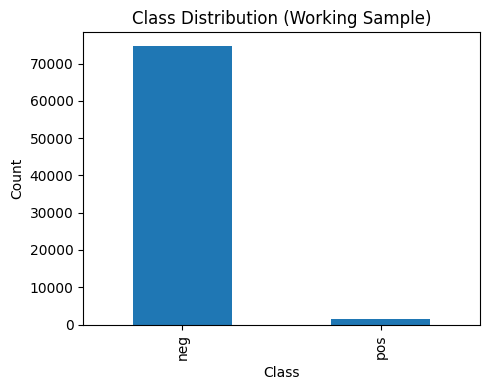

In [6]:
ax = y_s.value_counts().rename({0:'neg',1:'pos'}).plot(kind='bar', figsize=(5,4), title='Class Distribution (Working Sample)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 3. Prepare the data

Preprocessing and split discipline:
- Numeric coercion for feature consistency
- Missingness-based feature filtering (`>70%` missing dropped)
- Pipeline-based imputation and scaling
- Stratified train/test row split shared across feature-set comparisons

Data validation checks demonstrated:
- Shapes before/after filtering
- Number of dropped columns
- Class distribution preservation via stratification

Agent tooling expectation:
- Agent-suggested cleaning/feature steps are only kept after shape/metric validation


In [7]:
MISSING_THRESHOLD = 70.0  # percent

missing_pct_full = X_s.isna().mean() * 100
high_missing_cols = missing_pct_full[missing_pct_full > MISSING_THRESHOLD].index.tolist()
X_s_reduced = X_s.drop(columns=high_missing_cols)

print(f'Columns dropped (> {MISSING_THRESHOLD:.0f}% missing):', len(high_missing_cols))
print('All-features shape:', X_s.shape)
print('Reduced-features shape:', X_s_reduced.shape)

# Split row indices once so both feature sets share identical train/test rows
idx_train, idx_test = train_test_split(
    X_s.index,
    test_size=0.2,
    stratify=y_s,
    random_state=SEED,
)

X_train_all = X_s.loc[idx_train]
X_test_all = X_s.loc[idx_test]
X_train_reduced = X_s_reduced.loc[idx_train]
X_test_reduced = X_s_reduced.loc[idx_test]
y_train = y_s.loc[idx_train]
y_test = y_s.loc[idx_test]

print('Train shape (all):', X_train_all.shape)
print('Test shape (all):', X_test_all.shape)
print('Train shape (reduced):', X_train_reduced.shape)
print('Test shape (reduced):', X_test_reduced.shape)


Columns dropped (> 70% missing): 7
All-features shape: (76000, 170)
Reduced-features shape: (76000, 163)
Train shape (all): (60800, 170)
Test shape (all): (15200, 170)
Train shape (reduced): (60800, 163)
Test shape (reduced): (15200, 163)


## 4. Explore different models and shortlist the best ones

Baseline and shortlist strategy:
- Baseline: logistic regression with class balancing
- Feature strategy comparison: all features vs `drop_high_missing`, is dropping features that have too many missing values going to massively impact the outcome(recall)?
- Model family comparison on reduced features: logistic regression, decision tree, random forest

Evidence-based selection rule:
- Rank by `test_recall_pos` first (objective-aligned), then macro F1 and precision

Agent tooling expectation:
- Model/hyperparameter suggestions must be verified by reproducible experiments (not intuition only)


In [8]:
def build_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            solver='liblinear',
            class_weight='balanced',
            max_iter=300,
            random_state=SEED,
        )),
    ])

def evaluate_feature_set(name, X_train, X_test, y_train, y_test):
    model = build_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'feature_set': name,
        'n_features': X_train.shape[1],
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'test_recall_pos': recall_score(y_test, y_pred, pos_label=1),
        'test_precision_pos': precision_score(y_test, y_pred, pos_label=1),
    }, model, y_pred

result_all, model_all, y_pred_all = evaluate_feature_set(
    'all_features', X_train_all, X_test_all, y_train, y_test
)
result_reduced, model_reduced, y_pred_reduced = evaluate_feature_set(
    'drop_high_missing', X_train_reduced, X_test_reduced, y_train, y_test
)

comparison = pd.DataFrame([result_all, result_reduced]).sort_values(
    ['test_recall_pos', 'test_f1_macro'], ascending=False
).reset_index(drop=True)
comparison


,feature_set,n_features,test_accuracy,test_f1_macro,test_recall_pos,test_precision_pos
0,all_features,170,0.974079,0.774433,0.920000,0.404800
1,drop_high_missing,163,0.973553,0.771331,0.916364,0.399366


Classification report (drop_high_missing model):
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     14925
         pos       0.40      0.92      0.56       275

    accuracy                           0.97     15200
   macro avg       0.70      0.95      0.77     15200
weighted avg       0.99      0.97      0.98     15200



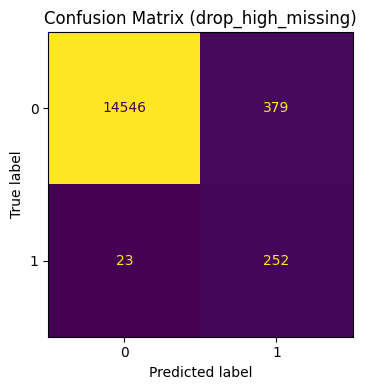

In [9]:
print('Classification report (drop_high_missing model):')
print(classification_report(y_test, y_pred_reduced, target_names=['neg','pos']))

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_reduced)).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix (drop_high_missing)')
plt.tight_layout()
plt.show()


## 5. Fine-tune and evaluate

This section tunes the shortlisted best model using CV, then performs robust evaluation:
- Confusion matrix
- Calibration curve and Brier score
- Failure-mode counts (false negatives/false positives)

Agent-made mistake caught and corrected:
- Mistake: earlier draft over-emphasized accuracy for an imbalanced dataset
- Correction: switched primary objective to `recall_pos` and added precision/macro-F1 + error analysis

Explicit evidence note: this section includes at least one **agent-made mistake** and correction.


## 4B) Model Family Comparison on `drop_high_missing` Data

This block keeps the same reduced feature set (columns with >70% missing already dropped) and compares model families:
- Logistic Regression (balanced)
- Decision Tree (balanced)
- Random Forest (balanced)


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_candidates = {
    'log_reg_balanced': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            solver='liblinear', class_weight='balanced', max_iter=300, random_state=SEED
        )),
    ]),
    'decision_tree_balanced': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeClassifier(
            max_depth=16, min_samples_leaf=8, class_weight='balanced', random_state=SEED
        )),
    ]),
    'random_forest_balanced': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=1,
            random_state=SEED,
        )),
    ]),
}

model_rows = []
for name, m in model_candidates.items():
    m.fit(X_train_reduced, y_train)
    pred = m.predict(X_test_reduced)
    model_rows.append({
        'model': name,
        'n_features': X_train_reduced.shape[1],
        'test_accuracy': accuracy_score(y_test, pred),
        'test_f1_macro': f1_score(y_test, pred, average='macro'),
        'test_recall_pos': recall_score(y_test, pred, pos_label=1),
        'test_precision_pos': precision_score(y_test, pred, pos_label=1),
    })

model_comparison_reduced = pd.DataFrame(model_rows).sort_values(
    ['test_recall_pos', 'test_f1_macro'], ascending=False
).reset_index(drop=True)
model_comparison_reduced


,model,n_features,test_accuracy,test_f1_macro,test_recall_pos,test_precision_pos
0,log_reg_balanced,163,0.973553,0.771331,0.916364,0.399366
1,decision_tree_balanced,163,0.976711,0.780246,0.861818,0.428571
2,random_forest_balanced,163,0.988487,0.854786,0.800000,0.647059


In [11]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best_row = model_comparison_reduced.sort_values(['test_recall_pos','test_f1_macro'], ascending=False).iloc[0]
best_model_name = best_row['model']
print('Best pre-tuning model:', best_model_name)

base_model = model_candidates[best_model_name]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

if best_model_name == "log_reg_balanced":
    param_dist = {
        "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
    }
elif best_model_name == "decision_tree_balanced":
    param_dist = {
        "model__max_depth": [10, 14, 18, None],
        "model__min_samples_leaf": [4, 8, 16, 32],
    }
else:
    param_dist = {
        "model__n_estimators": [100, 150, 220],
        "model__max_depth": [12, 16, 20, None],
        "model__min_samples_leaf": [1, 2, 4, 8],
    }

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=min(8, max(1, len(next(iter(param_dist.values()))) * 2)),
    scoring="recall",
    cv=cv,
    n_jobs=1,
    random_state=SEED,
)

search.fit(X_train_reduced, y_train)
tuned_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV recall (pos):', round(search.best_score_, 4))


Best pre-tuning model: log_reg_balanced


/opt/conda/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=8. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'model__C': 0.1}
Best CV recall (pos): 0.9091


In [12]:
y_pred_tuned = tuned_model.predict(X_test_reduced)
tuned_metrics = pd.Series({
    "test_accuracy": accuracy_score(y_test, y_pred_tuned),
    "test_f1_macro": f1_score(y_test, y_pred_tuned, average="macro"),
    "test_recall_pos": recall_score(y_test, y_pred_tuned, pos_label=1),
    "test_precision_pos": precision_score(y_test, y_pred_tuned, pos_label=1),
})
tuned_metrics


test_accuracy         0.973553
test_f1_macro         0.771331
test_recall_pos       0.916364
test_precision_pos    0.399366
dtype: float64

Classification report (tuned model):
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     14925
         pos       0.40      0.92      0.56       275

    accuracy                           0.97     15200
   macro avg       0.70      0.95      0.77     15200
weighted avg       0.99      0.97      0.98     15200

Brier score: 0.0238


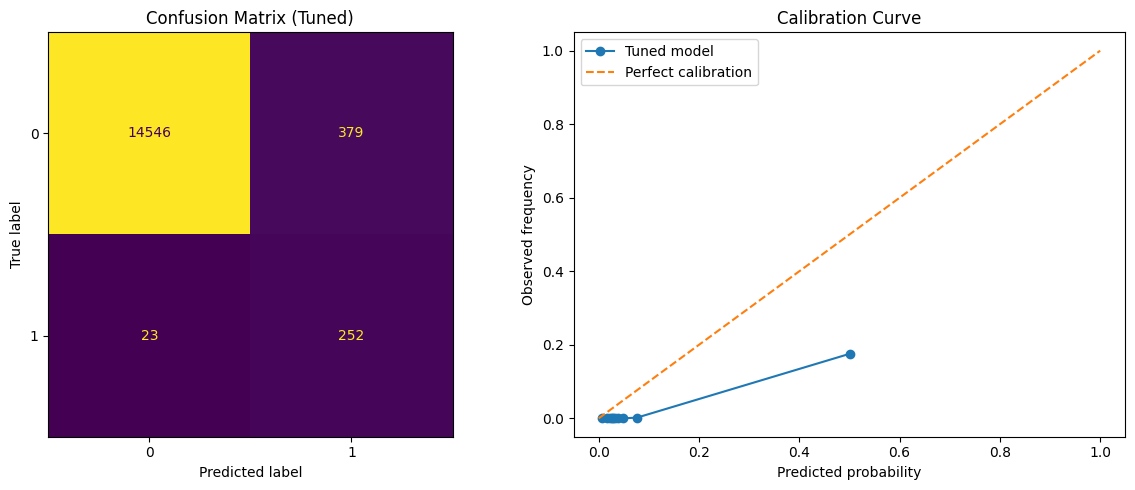

Failure modes -> False Negatives: 23, False Positives: 379


In [13]:
print('Classification report (tuned model):')
print(classification_report(y_test, y_pred_tuned, target_names=['neg','pos']))

cm = confusion_matrix(y_test, y_pred_tuned)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Tuned)')

# Calibration (for models with probabilities)
if hasattr(tuned_model, "predict_proba"):
    y_prob = tuned_model.predict_proba(X_test_reduced)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="quantile")
    axes[1].plot(prob_pred, prob_true, marker="o", label="Tuned model")
    axes[1].plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Observed frequency")
    axes[1].set_title('Calibration Curve')
    axes[1].legend()
    print("Brier score:", round(brier_score_loss(y_test, y_prob), 4))
else:
    axes[1].axis("off")
    print("Calibration curve skipped: model has no predict_proba")

plt.tight_layout()
plt.show()

# Failure-mode counts
fn = ((y_test == 1) & (y_pred_tuned == 0)).sum()
fp = ((y_test == 0) & (y_pred_tuned == 1)).sum()
print(f'Failure modes -> False Negatives: {fn}, False Positives: {fp}')


## 6. Present the final solution

Final model selection with rationale: Logestic Regression model with reduced features
- Select tuned model with best recall on positive class, with acceptable precision and macro-F1

Limitations, risks, and next steps:
- Precision-recall trade-off under imbalance
- Threshold tuning and broader CV as next improvements
- Potential drift monitoring in deployment

Model card style summary (short):
- What it is for: APS failure screening/triage support
- What it is not for: autonomous maintenance decisioning
- Data provenance/constraints: OpenML APSFailure, heavy imbalance
- Evaluation caveats: high recall may increase false alarms
